## Week 6: ARMA family models

In [42]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import statsmodels.graphics.tsaplots as sgt
import statsmodels.tsa.stattools as sts

In [44]:
data = pd.read_csv("data6_GDP_Q_real_SA.csv", header = 0, index_col = 0)
data.index = pd.to_datetime(data.index)

<Axes: xlabel='DATE'>

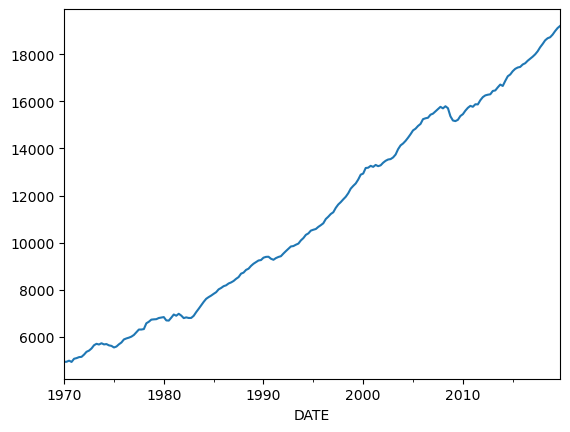

In [46]:
data = data['1970':'2019']
data.columns = ['gdp']
data['gdpgr'] = data.gdp.pct_change() * 100
data.gdp.plot()

Text(0.5, 1.0, 'ACF for GDP ')

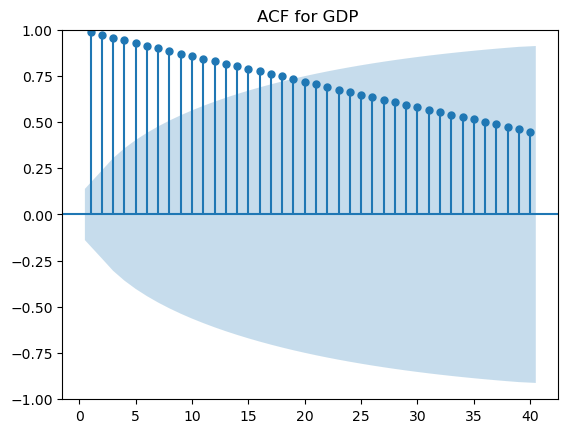

In [48]:
sgt.plot_acf(data.gdp, zero = False, lags = 40 )
plt.title("ACF for GDP ")

Text(0.5, 1.0, 'ACF for GDP growth ')

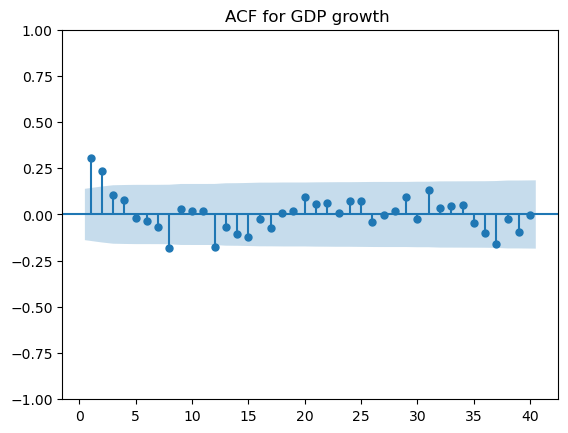

In [50]:
sgt.plot_acf(data.gdpgr[1:], zero = False, lags = 40 )
plt.title("ACF for GDP growth ")

<Axes: xlabel='DATE'>

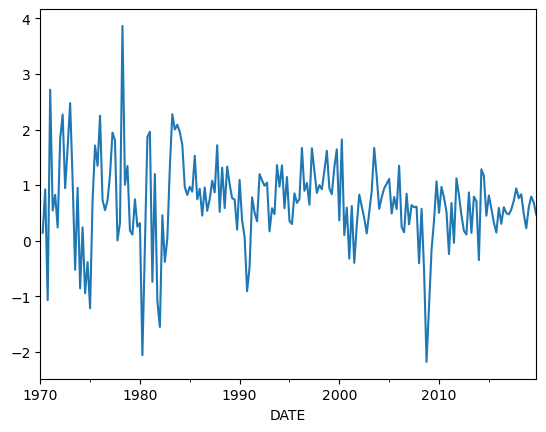

In [52]:
data.gdpgr.plot()

Text(0.5, 1.0, 'PACF for GDP growth ')

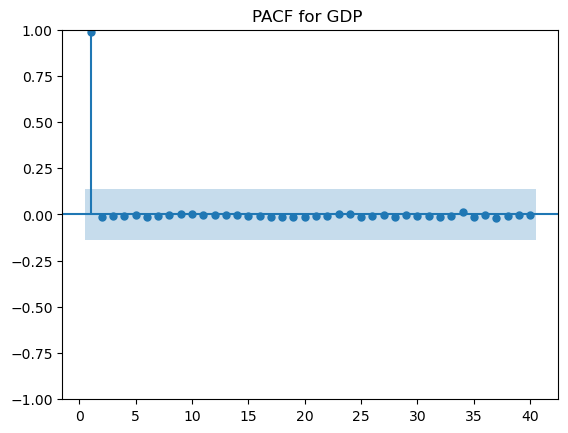

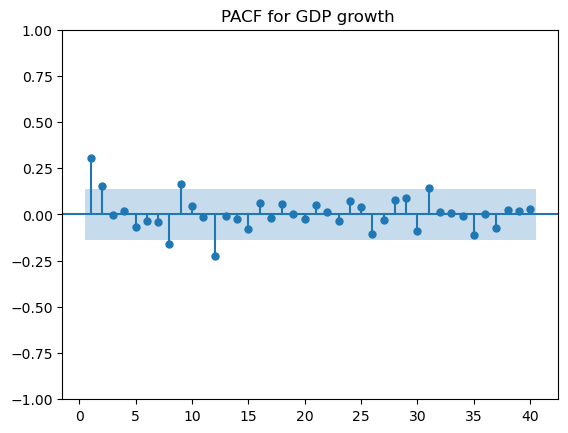

In [54]:
sgt.plot_pacf(data.gdp, zero = False, lags = 40 )
plt.title("PACF for GDP ")

sgt.plot_pacf(data.gdpgr[1:], zero = False, lags = 40 )
plt.title("PACF for GDP growth ")

In [56]:
from statsmodels.tsa.arima.model import ARIMA

In [58]:
gdp_ar1 = ARIMA(data.gdp, order =(1,0,0))
res_gdp_ar1 = gdp_ar1.fit()
res_gdp_ar1.summary()

/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency QS-OCT will be used.
  self._init_dates(dates, freq)
/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency QS-OCT will be used.
  self._init_dates(dates, freq)
/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency QS-OCT will be used.
  self._init_dates(dates, freq)
/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'


<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                    gdp   No. Observations:                  200
Model:                 ARIMA(1, 0, 0)   Log Likelihood               -1216.900
Date:                Mon, 24 Feb 2025   AIC                           2439.800
Time:                        16:01:05   BIC                           2449.695
Sample:                    01-01-1970   HQIC                          2443.804
                         - 10-01-2019                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const       1.119e+04   1.41e+04      0.793      0.427   -1.65e+04    3.88e+04
ar.L1          0.9999      0.002    552.362      0.000       0.996       1.003
sigma2      1.082e+04   1249.706      8.661      0.000    8374.286    1.33e+04
===================================================================================
Ljung-Box (L1) (Q):                  28.42   Jarque-Bera (JB):               178.32
Prob(Q):                              0.00   Prob(JB):                         0.00
Heteroskedasticity (H):               2.04   Skew:                            -1.14
Prob(H) (two-sided):                  0.00   Kurtosis:                         7.02
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [60]:
sts.adfuller(data.gdp)

(1.7349466927577004,
 0.9982108779124726,
 12,
 187,
 {'1%': -3.465811691080702,
  '5%': -2.877123351472649,
  '10%': -2.5750770662586864},
 2088.5874311542148)

In [62]:
sts.adfuller(data.gdpgr[1:])

(-5.069113717319684,
 1.61686325302521e-05,
 11,
 187,
 {'1%': -3.465811691080702,
  '5%': -2.877123351472649,
  '10%': -2.5750770662586864},
 383.6913210486165)

In [64]:
gdpgr_ar1 = ARIMA(data.gdpgr[1:], order = (1,0,0))
res_gdpgr_ar1 = gdpgr_ar1.fit()
res_gdpgr_ar1.summary()  

/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency QS-OCT will be used.
  self._init_dates(dates, freq)
/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency QS-OCT will be used.
  self._init_dates(dates, freq)
/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency QS-OCT will be used.
  self._init_dates(dates, freq)


<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                  gdpgr   No. Observations:                  199
Model:                 ARIMA(1, 0, 0)   Log Likelihood                -225.221
Date:                Mon, 24 Feb 2025   AIC                            456.443
Time:                        16:01:12   BIC                            466.322
Sample:                    04-01-1970   HQIC                           460.441
                         - 10-01-2019                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.6860      0.078      8.809      0.000       0.533       0.839
ar.L1          0.3049      0.058      5.237      0.000       0.191       0.419
sigma2         0.5628      0.036     15.543      0.000       0.492       0.634
===================================================================================
Ljung-Box (L1) (Q):                   0.43   Jarque-Bera (JB):                68.39
Prob(Q):                              0.51   Prob(JB):                         0.00
Heteroskedasticity (H):               0.25   Skew:                            -0.03
Prob(H) (two-sided):                  0.00   Kurtosis:                         5.87
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [66]:
gdpgr_ar2 = ARIMA(data.gdpgr[1:], order = (2,0,0))
res_gdpgr_ar2 = gdpgr_ar2.fit()
res_gdpgr_ar2.summary()

/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency QS-OCT will be used.
  self._init_dates(dates, freq)
/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency QS-OCT will be used.
  self._init_dates(dates, freq)
/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency QS-OCT will be used.
  self._init_dates(dates, freq)


<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                  gdpgr   No. Observations:                  199
Model:                 ARIMA(2, 0, 0)   Log Likelihood                -222.835
Date:                Mon, 24 Feb 2025   AIC                            453.671
Time:                        16:01:19   BIC                            466.844
Sample:                    04-01-1970   HQIC                           459.002
                         - 10-01-2019                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.6853      0.093      7.377      0.000       0.503       0.867
ar.L1          0.2574      0.060      4.308      0.000       0.140       0.375
ar.L2          0.1535      0.060      2.579      0.010       0.037       0.270
sigma2         0.5493      0.035     15.900      0.000       0.482       0.617
===================================================================================
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):                86.11
Prob(Q):                              0.99   Prob(JB):                         0.00
Heteroskedasticity (H):               0.25   Skew:                             0.08
Prob(H) (two-sided):                  0.00   Kurtosis:                         6.22
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [68]:
from scipy.stats.distributions import chi2

In [70]:
def LLR_test(model1, model2, DF=1):
    L1 = model1.fit().llf
    L2 = model2.fit().llf
    LR = -2*(L1-L2)
    p = chi2.sf(LR, DF).round(3)
    return p

In [72]:
LLR_test(gdpgr_ar1, gdpgr_ar2, 1)

0.029

In [74]:
data['res_ar'] = res_gdpgr_ar2.resid

<Axes: xlabel='DATE'>

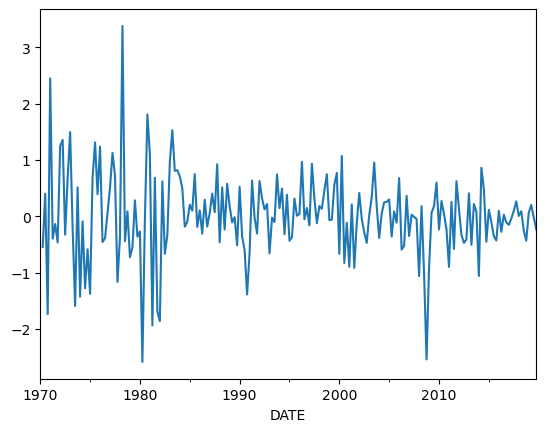

In [76]:
data.res_ar.plot()

In [78]:
sts.adfuller(data.res_ar[1:])

(-4.932016573965116,
 3.0200719733540916e-05,
 11,
 187,
 {'1%': -3.465811691080702,
  '5%': -2.877123351472649,
  '10%': -2.5750770662586864},
 384.61865422582565)